### Step 1: Import Libraries

In [7]:
import numpy as np
import cv2
from cv2 import dnn
import matplotlib.pyplot as plt

### Step 2: Reading the Model Parameters

In [146]:
proto_file = './data/colorization_deploy_v2.prototxt'
model_file = './data/colorization_release_v2.caffemodel'
hull_pts = './data/pts_in_hull.npy'
img_path = './data/ansel_adams.jpg'

In [98]:
net = dnn.readNetFromCaffe(proto_file, model_file)
kernel = np.load(hull_pts)

### Step 3: Reading and Preprocessing Image

In [147]:
img = cv2.imread(img_path)

In [148]:
img.shape

(2402, 3000, 3)

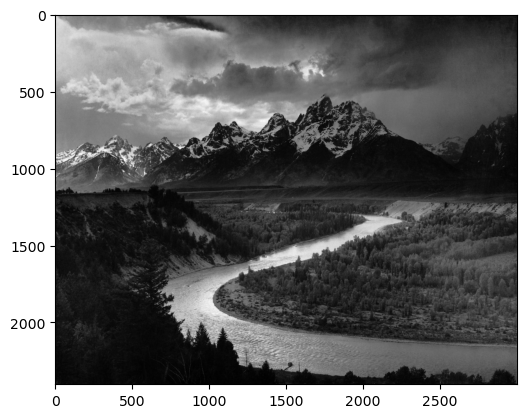

In [149]:
plt.imshow(img)

In [150]:
scaled = img.astype(np.float32) / 255.0

In [151]:
lab_img = cv2.cvtColor(scaled, cv2.COLOR_BGR2LAB)

In [152]:
resized = cv2.resize(lab_img, (224, 224))

In [179]:
L = cv2.split(resized)[0]

In [180]:
L -= 50

### Step 4: Add the Cluster Centers

In [115]:
class8 = net.getLayerId('class8_ab')
conv8 = net.getLayerId('conv8_313_rh')

In [116]:
pts = kernel.transpose().reshape(2, 313, 1, 1)

In [117]:
net.getLayer(class8).blobs = [pts.astype(np.float32)]
net.getLayer(conv8).blobs = [np.full([1, 313], 2.606, dtype=np.float32)]

### Step 5: Predicting the ab Channels

In [181]:
net.setInput(cv2.dnn.blobFromImage(L))

In [182]:
ab_channel = net.forward()[0, :, :, :].transpose((1, 2, 0))

In [183]:
ab_channel = cv2.resize(ab_channel, (img.shape[1], img.shape[0]))

### Step 6: Generate Final Image

In [185]:
L = cv2.split(lab_img)[0]

In [186]:
colorized = np.concatenate((L[:, :, np.newaxis], ab_channel), axis=2)

In [187]:
colorized = cv2.cvtColor(colorized, cv2.COLOR_LAB2RGB)

In [188]:
colorized = np.clip(colorized, 0, 1)

In [189]:
colorized = (255 * colorized).astype("uint8")

(-0.5, 2999.5, 2401.5, -0.5)

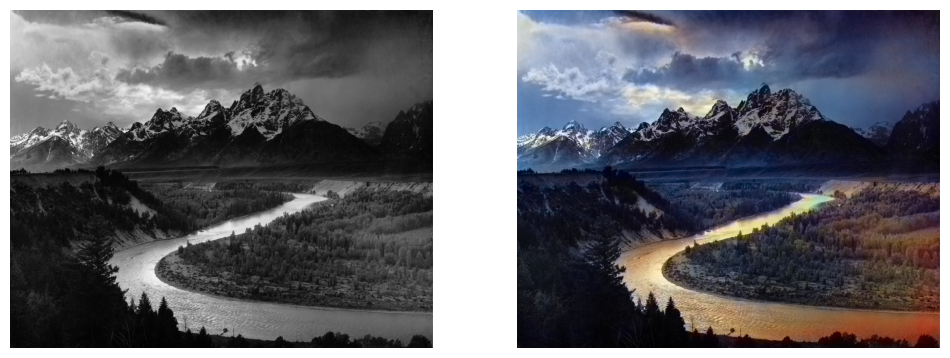

In [190]:
fig, ax = plt.subplots(1, 2, figsize=(12, 12))
ax[0].imshow(img)
ax[0].axis('off')
ax[1].imshow(colorized)
ax[1].axis('off')